# Лабораторная работа №3 ОБУЧЕНИЕ С УЧИТЕЛЕМ. ЗАДАЧА КЛАССИФИКАЦИИ 

## Загрузка и подготовка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, RocCurveDisplay, classification_report

import optuna
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from scipy.stats import uniform, randint

from my_metrics_class import *
from my_algs import MyKNNClassifier



RNG_SEED = 42
np.random.seed(seed=RNG_SEED)

### Загрузка датасета

In [2]:
df = pd.read_csv('../data/final_data_wine.csv')
df

,Unnamed: 0,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,0,7.4,0.70,0.00,1.9,0.076,11,34,0.99780,3.51,0.56,9.4,5,1
1,1,7.8,0.88,0.00,2.6,0.098,25,67,0.99680,3.20,0.68,9.8,5,1
2,2,7.8,0.76,0.04,2.3,0.092,15,54,0.99700,3.26,0.65,9.8,5,1
3,3,11.2,0.28,0.56,1.9,0.075,17,60,0.99800,3.16,0.58,9.8,6,1
4,4,7.4,0.70,0.00,1.9,0.076,11,34,0.99780,3.51,0.56,9.4,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6016,4893,6.2,0.21,0.29,1.6,0.039,24,92,0.99114,3.27,0.50,11.2,6,0
6017,4894,6.6,0.32,0.36,8.0,0.047,57,168,0.99490,3.15,0.46,9.6,5,0
6018,4895,6.5,0.24,0.19,1.2,0.041,30,111,0.99254,2.99,0.46,9.4,6,0
6019,4896,5.5,0.29,0.30,1.1,0.022,20,110,0.98869,3.34,0.38,12.8,7,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6021 entries, 0 to 6020
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            6021 non-null   int64  
 1   fixed acidity         6021 non-null   float64
 2   volatile acidity      6021 non-null   float64
 3   citric acid           6021 non-null   float64
 4   residual sugar        6021 non-null   float64
 5   chlorides             6021 non-null   float64
 6   free sulfur dioxide   6021 non-null   int64  
 7   total sulfur dioxide  6021 non-null   int64  
 8   density               6021 non-null   float64
 9   pH                    6021 non-null   float64
 10  sulphates             6021 non-null   float64
 11  alcohol               6021 non-null   float64
 12  quality               6021 non-null   int64  
 13  type                  6021 non-null   int64  
dtypes: float64(9), int64(5)
memory usage: 658.7 KB


### Выделеение целевого признака и предиктора, разделение на выборки

In [4]:
X = df.drop(columns=['type'])
y = df['type']
print(X.shape, y.shape)
print(y.value_counts())

(6021, 13) (6021,)
type
0    4600
1    1421
Name: count, dtype: int64


### Разделение данных

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=42, stratify=y
)

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RNG_SEED)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RNG_SEED)

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, X_val.shape, y_test.shape)


(3612, 13) (1204, 13) (1205, 13)
(3612,) (1204, 13) (1205,)


Задача бинарной классификации (2 признака 0,1 - белое и красное вино). В данных имеется явный дисбаланс классов - красного вина в 4 раза меньше белого

### Балансировка

In [6]:
y_train.value_counts()

type
0    2759
1     853
Name: count, dtype: int64

In [7]:
oversample = SMOTE()

X_train_bal, y_train_bal = oversample.fit_resample(X_train, y_train)
y_train_bal.value_counts()

type
0    2759
1    2759
Name: count, dtype: int64

### Вспомогательные функции

In [8]:
def calculate_metrics(y_true, y_pred):
    return {
        'F1': f1_score(y_true, y_pred),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred)
    }

def print_cv_results_table(cv_scores, model_name="Model"):
    metric_mapping = {
        'F1': 'test_f1_weighted',
        'Accuracy': 'test_accuracy',
        'Precision': 'test_precision_weighted',
        'Recall': 'test_recall_weighted'
    }
    
    data = {'Fold': list(range(len(cv_scores['test_accuracy'])))}
    for col_name, key in metric_mapping.items():
        data[col_name] = cv_scores[key]
        
    df = pd.DataFrame(data).set_index('Fold')
    
    df.loc['Mean'] = df.mean()
    df.loc['Std'] = df.std()
    
    print(f"\nРезультаты 10-Fold CV для {model_name}")
    display(df.style.format('{:.4f}').apply(
        lambda row: ['background-color: #FFFF00' if row.name == 'Mean' else '' for _ in row], 
        axis=1
    ))

def fmt(val, metric_name):
    prec = 2 if metric_name == 'F1' else 4
    return f"{val:.{prec}f}"

## Основные классификаторы


 Обучение: Logistic Regression

Результаты 10-Fold CV для Logistic Regression


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.9747,0.9752,0.9760,0.9752
1,0.9669,0.9669,0.9669,0.9669
2,0.9483,0.9504,0.9534,0.9504
3,0.9835,0.9835,0.9835,0.9835
4,0.9916,0.9917,0.9918,0.9917
5,1.0000,1.0000,1.0000,1.0000
6,0.9516,0.9500,0.9588,0.9500
7,0.9835,0.9833,0.9844,0.9833
8,0.9752,0.9750,0.9755,0.9750


Test F1: 0.99 | Acc: 0.9959
Confusion Matrix:
 [[918   3]
 [  2 282]]


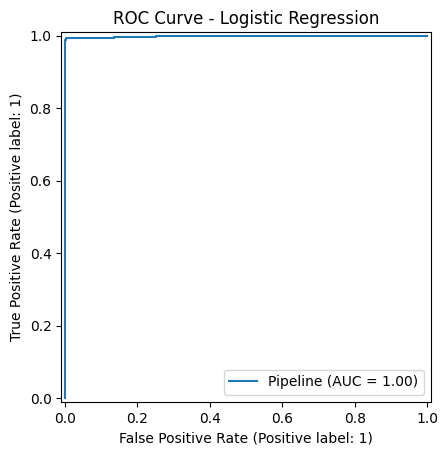


 Обучение: kNN

Результаты 10-Fold CV для kNN


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.9510,0.9504,0.9522,0.9504
1,0.9252,0.9256,0.9249,0.9256
2,0.9300,0.9339,0.9392,0.9339
3,0.9321,0.9339,0.9333,0.9339
4,0.9748,0.9750,0.9749,0.9750
5,0.9916,0.9917,0.9918,0.9917
6,0.9263,0.9250,0.9290,0.9250
7,0.9506,0.9500,0.9519,0.9500
8,0.9235,0.9250,0.9236,0.9250


Test F1: 0.99 | Acc: 0.9959
Confusion Matrix:
 [[918   3]
 [  2 282]]


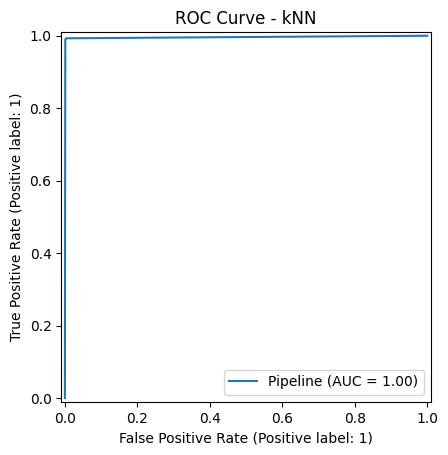


 Обучение: Naive Bayes

Результаты 10-Fold CV для Naive Bayes


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.9597,0.9587,0.9648,0.9587
1,0.9837,0.9835,0.9845,0.9835
2,0.9833,0.9835,0.9838,0.9835
3,0.9756,0.9752,0.9775,0.9752
4,1.0000,1.0000,1.0000,1.0000
5,1.0000,1.0000,1.0000,1.0000
6,0.9516,0.9500,0.9588,0.9500
7,0.9754,0.9750,0.9774,0.9750
8,0.9590,0.9583,0.9613,0.9583


Test F1: 0.98 | Acc: 0.9909
Confusion Matrix:
 [[915   6]
 [  5 279]]


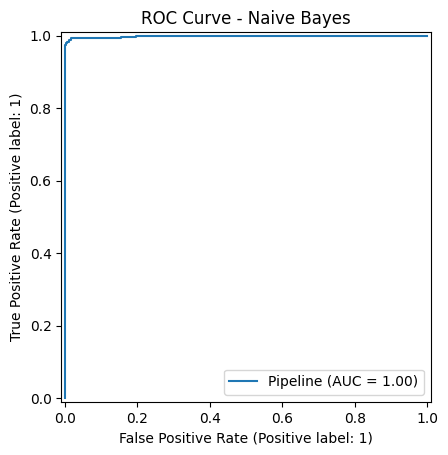


 Обучение: SVC (Linear)

Результаты 10-Fold CV для SVC (Linear)


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.9833,0.9835,0.9838,0.9835
1,1.0000,1.0000,1.0000,1.0000
2,0.9747,0.9752,0.9760,0.9752
3,0.9835,0.9835,0.9835,0.9835
4,0.9916,0.9917,0.9918,0.9917
5,1.0000,1.0000,1.0000,1.0000
6,0.9754,0.9750,0.9774,0.9750
7,0.9835,0.9833,0.9844,0.9833
8,0.9916,0.9917,0.9918,0.9917


Test F1: 0.99 | Acc: 0.9967
Confusion Matrix:
 [[919   2]
 [  2 282]]


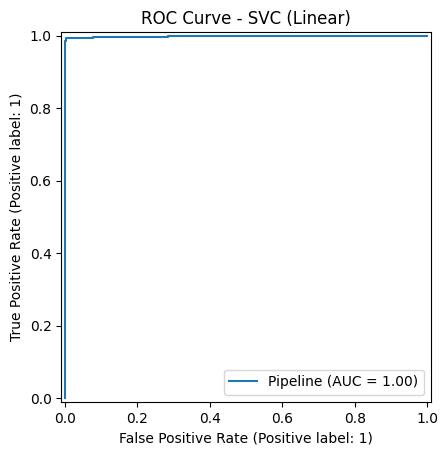

In [ ]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RNG_SEED),
    "kNN": KNeighborsClassifier(n_neighbors=3),
    "Naive Bayes": GaussianNB(),
    "SVC (Linear)": SVC(kernel='linear', random_state=RNG_SEED, cache_size=8000, probability=False),
    "SVC (Poly)": SVC(kernel='poly', random_state=RNG_SEED, cache_size=8000, probability=False),
    "SVC (Sigmoid)": SVC(kernel='sigmoid', random_state=RNG_SEED, cache_size=8000, probability=False)
}

holdout_results = []
cv_results = []
trained_models = {}

cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=RNG_SEED)
metrics_list = ['F1', 'Accuracy', 'Precision', 'Recall']

for name, clf in classifiers.items():
    print(f"\n Обучение: {name}")
    
    cv_scores = cross_validate(
        clf, X_val, y_val, cv=cv_strategy,
        scoring=['f1_weighted', 'accuracy', 'precision_weighted', 'recall_weighted'],
        n_jobs=-1
    )
    
    cv_row = {"Classifier": name}
    for key, met in zip(['f1_weighted', 'accuracy', 'precision_weighted', 'recall_weighted'], metrics_list):
        mean_v, std_v = cv_scores[f'test_{key}'].mean(), cv_scores[f'test_{key}'].std()
        cv_row[('K-fold (CV)', met)] = f"{mean_v:.2f} ± {std_v:.2f}" if met == 'F1' else f"{mean_v:.4f} ± {std_v:.4f}"
    cv_results.append(cv_row)

    print_cv_results_table(cv_scores, model_name=name)
    
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', clf)
    ])

    model.fit(X_train_bal, y_train_bal)
    trained_models[name] = model
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_m = calculate_metrics(y_train, y_train_pred)
    test_m = calculate_metrics(y_test, y_test_pred)
    
    row_holdout = {'Classifier': name}
    for metric in metrics_list:
        row_holdout[('Train Data', metric)] = fmt(train_m[metric], metric)
        row_holdout[('Test Data', metric)]  = fmt(test_m[metric], metric)
    holdout_results.append(row_holdout)
    
    print(f"Test F1: {test_m['F1']:.2f} | Acc: {test_m['Accuracy']:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
    
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f'ROC Curve - {name}')
    plt.show()


In [10]:
holdout_results

[{'Classifier': 'Logistic Regression',
  ('Train Data', 'F1'): '1.00',
  ('Test Data', 'F1'): '0.99',
  ('Train Data', 'Accuracy'): '0.9981',
  ('Test Data', 'Accuracy'): '0.9959',
  ('Train Data', 'Precision'): '0.9953',
  ('Test Data', 'Precision'): '0.9895',
  ('Train Data', 'Recall'): '0.9965',
  ('Test Data', 'Recall'): '0.9930'},
 {'Classifier': 'kNN',
  ('Train Data', 'F1'): '1.00',
  ('Test Data', 'F1'): '0.99',
  ('Train Data', 'Accuracy'): '0.9986',
  ('Test Data', 'Accuracy'): '0.9959',
  ('Train Data', 'Precision'): '0.9942',
  ('Test Data', 'Precision'): '0.9895',
  ('Train Data', 'Recall'): '1.0000',
  ('Test Data', 'Recall'): '0.9930'},
 {'Classifier': 'Naive Bayes',
  ('Train Data', 'F1'): '0.98',
  ('Test Data', 'F1'): '0.98',
  ('Train Data', 'Accuracy'): '0.9922',
  ('Test Data', 'Accuracy'): '0.9909',
  ('Train Data', 'Precision'): '0.9747',
  ('Test Data', 'Precision'): '0.9789',
  ('Train Data', 'Recall'): '0.9930',
  ('Test Data', 'Recall'): '0.9824'},
 {'Classif

In [11]:
cv_results

[{'Classifier': 'Logistic Regression',
  ('K-fold (CV)', 'F1'): '0.97 ± 0.02',
  ('K-fold (CV)', 'Accuracy'): '0.9734 ± 0.0161',
  ('K-fold (CV)', 'Precision'): '0.9748 ± 0.0147',
  ('K-fold (CV)', 'Recall'): '0.9734 ± 0.0161'},
 {'Classifier': 'kNN',
  ('K-fold (CV)', 'F1'): '0.94 ± 0.02',
  ('K-fold (CV)', 'Accuracy'): '0.9427 ± 0.0230',
  ('K-fold (CV)', 'Precision'): '0.9437 ± 0.0229',
  ('K-fold (CV)', 'Recall'): '0.9427 ± 0.0230'},
 {'Classifier': 'Naive Bayes',
  ('K-fold (CV)', 'F1'): '0.98 ± 0.02',
  ('K-fold (CV)', 'Accuracy'): '0.9751 ± 0.0162',
  ('K-fold (CV)', 'Precision'): '0.9775 ± 0.0141',
  ('K-fold (CV)', 'Recall'): '0.9751 ± 0.0162'},
 {'Classifier': 'SVC (Linear)',
  ('K-fold (CV)', 'F1'): '0.98 ± 0.01',
  ('K-fold (CV)', 'Accuracy'): '0.9850 ± 0.0104',
  ('K-fold (CV)', 'Precision'): '0.9855 ± 0.0101',
  ('K-fold (CV)', 'Recall'): '0.9850 ± 0.0104'}]

По предоставленным результатам видно, что все модели достаточно хорошо отработали (f1)

## Оптимизация grid, random, optuna

In [ ]:
PARAM_CONFIGS = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
    },
    "kNN": {
        "n_neighbors": [1, 3, 5, 7, 9],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan", "chebyshev"]
    },
    "Naive Bayes": {
        "var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]
    },
    "SVC (Linear)": {
        "C": [0.01, 0.1, 1, 10, 100]
    },
    "SVC (Poly)": {
       "C": [0.1, 1, 10],
         "degree": [2, 3, 4],
        "gamma": ["scale", "auto"],
        "coef0": [0.0, 0.5, 1.0]
    },
    "SVC (Sigmoid)": {
        "C": [0.1, 1, 10],
        "gamma": ["scale", "auto"],
        "coef0": [-1.0, 0.0, 1.0]
    }
}

In [13]:
def tune_model(base_model, model_name, method='grid'):
    params = PARAM_CONFIGS.get(model_name, {})
    if not params:
        print(f"   Параметры для {model_name} не заданы. Используется модель по умолчанию.")
        return base_model, {}

    print(f"   Оптимизация ({method.upper()}): {model_name}")
    
    if method == 'grid':
        search = GridSearchCV(base_model, params, cv=3, scoring='f1_weighted', n_jobs=-1)
        search.fit(X_train_bal, y_train_bal)
        best_params = search.best_params_
        print(f"   GridSearch выбрал: {best_params}")
        return search.best_estimator_, best_params
        
    elif method == 'random':
        search = RandomizedSearchCV(base_model, params, n_iter=15, cv=3, scoring='f1_weighted', n_jobs=-1, random_state=42)
        search.fit(X_train_bal, y_train_bal)
        best_params = search.best_params_
        print(f"   RandomizedSearch выбрал: {best_params}")
        return search.best_estimator_, best_params
        
    elif method == 'optuna':
        def objective(trial):
            tuned_params = {}
            for param_name, param_values in params.items():
                if all(isinstance(v, int) for v in param_values):
                    tuned_params[param_name] = trial.suggest_int(param_name, min(param_values), max(param_values))
                else:
                    tuned_params[param_name] = trial.suggest_categorical(param_name, param_values)
            clf = base_model.__class__(**tuned_params)
            return cross_val_score(clf, X_train_bal, y_train_bal, cv=3, scoring='f1_weighted').mean()
        
        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=20, show_progress_bar=False)
        best_params = study.best_params
        print(f"   Optuna выбрала: {best_params}")
        
        best_model = base_model.__class__(**best_params)
        best_model.fit(X_train_bal, y_train_bal)
        return best_model, best_params

## Визуализации

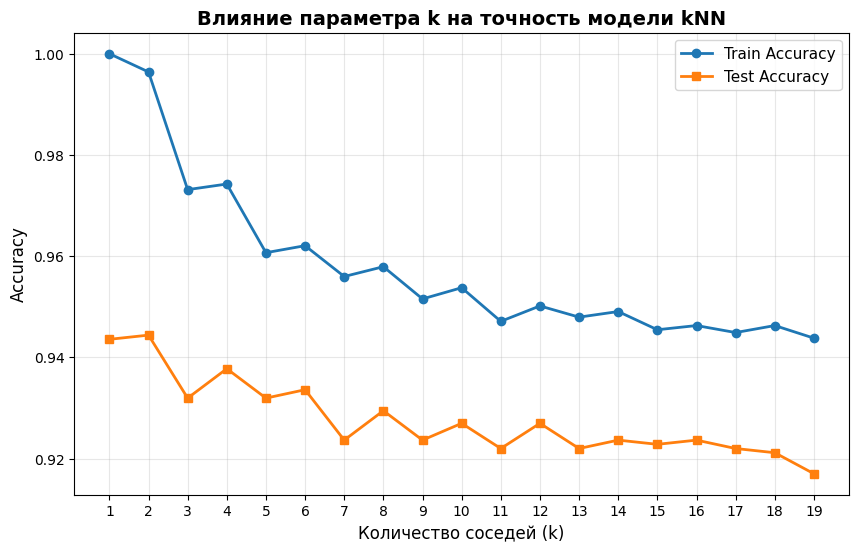

Оптимальное значение k: 2
Лучшая точность на тесте: 0.9444


In [14]:
k_values = range(1, 20)
train_scores = []
test_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_bal, y_train_bal)
    
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)
    
    train_scores.append(accuracy_score(y_train, y_train_pred))
    test_scores.append(accuracy_score(y_test, y_test_pred))

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, marker='o', label='Train Accuracy', linewidth=2)
plt.plot(k_values, test_scores, marker='s', label='Test Accuracy', linewidth=2)
plt.xlabel('Количество соседей (k)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Влияние параметра k на точность модели kNN', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.show()

optimal_k = k_values[np.argmax(test_scores)]
print(f"Оптимальное значение k: {optimal_k}")
print(f"Лучшая точность на тесте: {max(test_scores):.4f}")

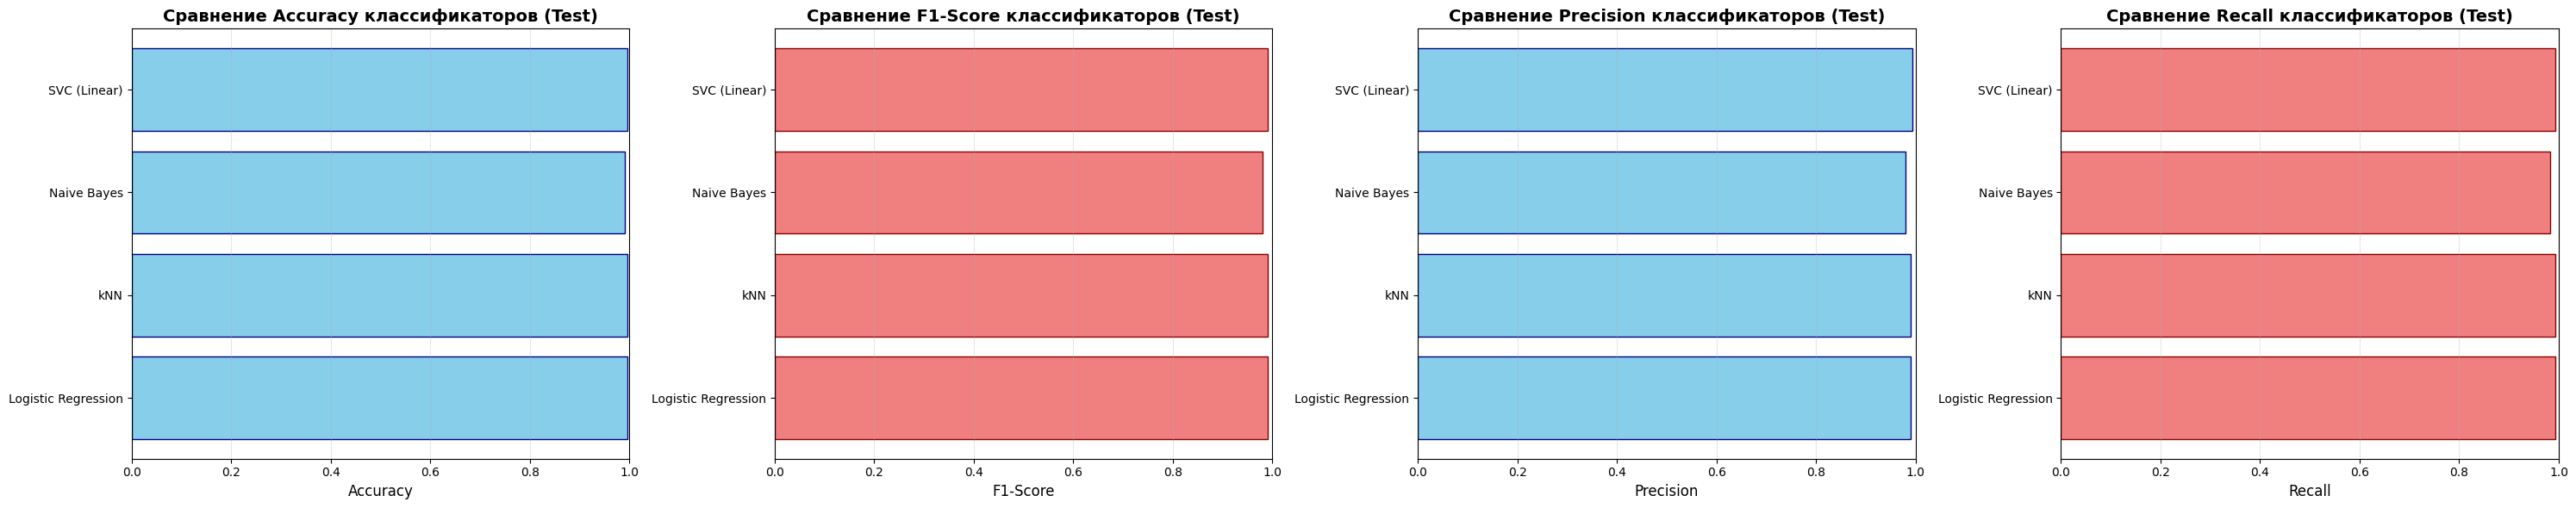

In [15]:
classifiers_names = [row['Classifier'] for row in holdout_results]
train_f1 = [float(row[('Train Data', 'F1')]) for row in holdout_results]
test_f1 = [float(row[('Test Data', 'F1')]) for row in holdout_results]
train_acc = [float(row[('Train Data', 'Precision')]) for row in holdout_results]
test_acc = [float(row[('Test Data', 'Accuracy')]) for row in holdout_results]
train_prec = [float(row[('Train Data', 'Precision')]) for row in holdout_results]
test_prec = [float(row[('Test Data', 'Precision')]) for row in holdout_results]
train_rec = [float(row[('Train Data', 'Recall')]) for row in holdout_results]
test_rec = [float(row[('Test Data', 'Recall')]) for row in holdout_results]

fig, axes = plt.subplots(1, 4, figsize=(30, 6))

axes[0].barh(classifiers_names, test_acc, color='skyblue', edgecolor='navy')
axes[0].set_xlabel('Accuracy', fontsize=12)
axes[0].set_title('Сравнение Accuracy классификаторов (Test)', fontsize=14, fontweight='bold')
axes[0].set_xlim([0, 1])
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(classifiers_names, test_f1, color='lightcoral', edgecolor='darkred')
axes[1].set_xlabel('F1-Score', fontsize=12)
axes[1].set_title('Сравнение F1-Score классификаторов (Test)', fontsize=14, fontweight='bold')
axes[1].set_xlim([0, 1])
axes[1].grid(axis='x', alpha=0.3)

axes[2].barh(classifiers_names, test_prec, color='skyblue', edgecolor='navy')
axes[2].set_xlabel('Precision', fontsize=12)
axes[2].set_title('Сравнение Precision классификаторов (Test)', fontsize=14, fontweight='bold')
axes[2].set_xlim([0, 1])
axes[2].grid(axis='x', alpha=0.3)

axes[3].barh(classifiers_names, test_rec, color='lightcoral', edgecolor='darkred')
axes[3].set_xlabel('Recall', fontsize=12)
axes[3].set_title('Сравнение Recall классификаторов (Test)', fontsize=14, fontweight='bold')
axes[3].set_xlim([0, 1])
axes[3].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

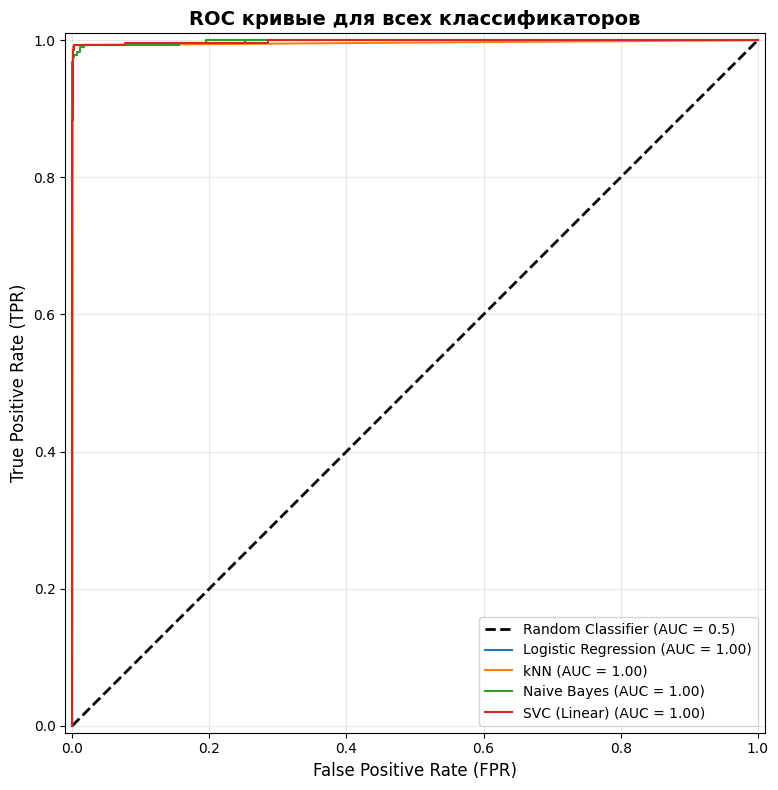

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.5)')

for name, model in trained_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name, plot_chance_level=False)

ax.set_title('ROC кривые для всех классификаторов', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Модели демонстрирует очень низкое количество ошибок обоих типов: всего 3 ошибки первого рода (0.33% от всех белых вин) и 1 ошибка второго рода (0.36% от всех красных вин). Это свидетельствует о высокой сбалансированности модели и её способности одинаково хорошо распознавать оба класса вин. Ошибки первого рода немного преобладают, что может быть связано с дисбалансом классов в исходных данных.

## Собственный KNN

In [17]:
knn_sklearn = KNeighborsClassifier(n_neighbors=2)
knn_sklearn.fit(X_train_bal, y_train_bal)
y_pred_sklearn_train = knn_sklearn.predict(X_train)
y_pred_sklearn_test = knn_sklearn.predict(X_test)

metrics_sklearn = {
    'Train': calculate_metrics(y_train, y_pred_sklearn_train),
    'Test': calculate_metrics(y_test, y_pred_sklearn_test)
}

metrics_sklearn
knn_custom = MyKNNClassifier(n_neighbors=2, metric='euclidean')
knn_custom.fit(X_train_bal, y_train_bal)
y_pred_custom_train = knn_custom.predict(X_train)
y_pred_custom_test = knn_custom.predict(X_test)

metrics_custom = {
    'Train': calculate_metrics(y_train, y_pred_custom_train),
    'Test': calculate_metrics(y_test, y_pred_custom_test)
}

In [18]:
comparison_data = {
    ('Train Data', 'F1'): [metrics_sklearn['Train']['F1'], metrics_custom['Train']['F1']],
    ('Train Data', 'Accuracy'): [metrics_sklearn['Train']['Accuracy'], metrics_custom['Train']['Accuracy']],
    ('Train Data', 'Precision'): [metrics_sklearn['Train']['Precision'], metrics_custom['Train']['Precision']],
    ('Train Data', 'Recall'): [metrics_sklearn['Train']['Recall'], metrics_custom['Train']['Recall']],
    ('Test Data', 'F1'): [metrics_sklearn['Test']['F1'], metrics_custom['Test']['F1']],
    ('Test Data', 'Accuracy'): [metrics_sklearn['Test']['Accuracy'], metrics_custom['Test']['Accuracy']],
    ('Test Data', 'Precision'): [metrics_sklearn['Test']['Precision'], metrics_custom['Test']['Precision']],
    ('Test Data', 'Recall'): [metrics_sklearn['Test']['Recall'], metrics_custom['Test']['Recall']]
}

df = pd.DataFrame(comparison_data, index=['kNN из Sklearn', 'программный kNN'])
df.index.name = 'Classifier'

display(df.style.set_caption("Образец 1: Сравнение kNN из Sklearn и собственной реализации")
        .format({
            ('Train Data', 'F1'): '{:.2f}',
            ('Train Data', 'Accuracy'): '{:.4f}',
            ('Train Data', 'Precision'): '{:.4f}',
            ('Train Data', 'Recall'): '{:.4f}',
            ('Test Data', 'F1'): '{:.2f}',
            ('Test Data', 'Accuracy'): '{:.4f}',
            ('Test Data', 'Precision'): '{:.4f}',
            ('Test Data', 'Recall'): '{:.4f}'
        }))

Итоговые значения некоторых метрик совпадают, но большинство из собственного knn хуже sciket. При реализация из scikit отрабатывает за долю сенкуды, а собственнася реализация требует несоизмеримо большего времени (3 минуты). Собственная реализация knn намного хуже по производительности

## Таблицы результатов

In [19]:
cols_2 = pd.MultiIndex.from_product([
    ['Train Data', 'Test Data'], 
    ['F1', 'Accuracy', 'Precision', 'Recall']
])
df_sample2 = pd.DataFrame(holdout_results).set_index('Classifier').reindex(columns=cols_2)

display(df_sample2.style.set_caption("Образец 2: Сравнение Train и Test"))

Из таблицы видно, что модели хорошо отработали на обоих выборках, и их метрики почти не отличаются, что говорит об остуствии переобучения и недообучения. Между собой модели практически не отличаются

In [20]:
cols_3 = pd.MultiIndex.from_product([
    ['Метод hold-out (test)', 'Метод k-fold (кросс-валидация)'],
    ['F1', 'Accuracy', 'Precision', 'Recall']
])


holdout_metrics = ['F1', 'Accuracy', 'Precision', 'Recall']
kfold_metrics = ['F1 (среднее ± std)', 'Accuracy (среднее ± std)', 
                 'Precision (среднее ± std)', 'Recall (среднее ± std)']

cols_3 = pd.MultiIndex.from_tuples(
    [('Метод hold-out (test)', m) for m in holdout_metrics] +
    [('Метод k-fold (кросс-валидация)', m) for m in kfold_metrics]
)

data_rows = []
for cv_row, hold_row in zip(cv_results, holdout_results):
    row = {'Classifier': cv_row['Classifier']}
    
    for metric in holdout_metrics:
        row[('Метод hold-out (test)', metric)] = hold_row[('Test Data', metric)]
    
    for metric, kfold_metric in zip(holdout_metrics, kfold_metrics):
        row[('Метод k-fold (кросс-валидация)', kfold_metric)] = cv_row[('K-fold (CV)', metric)]
    
    data_rows.append(row)

df_sample3 = pd.DataFrame(data_rows).set_index('Classifier')
df_sample3.columns = cols_3

display(df_sample3.style.set_caption("Образец 3: Сравнение hold-out и k-fold кросс-валидации"))

Анализируя конечную таблицу матрик, можно сделать выводы что:

- Лучшие модели: `KNN` (при этом `KNN` имеет наибольшее `std`), `SVC(linear)`
- Худший результат: Naive Bayes
- Поиск лучших параметров улучшил результаты, при этом разницы между `grid`, `random` и `optuna` почти нет

Все модели имеют минимальные отличия и подходят для решения задачи классификации

## Общие выводы

**Поиск гиперпараметров:**  
Рассмотрены три метода — `GridSearchCV`, `RandomizedSearchCV` и `Optuna`. Все они показали идентичные результаты

**Классификационные модели:**  
Обучены модели: Logistic Regression, kNN, Naive Bayes, SVC (Linear), SVC (Poly), SVC (Sigmoid), а также их оптимизированные версии.

Среди всех моделей наилучший результат показал **kNN после настройки гиперпараметров (`kNN_optuna`)**:
- F1 на тесте = **1.00**, Accuracy = **0.9983**
- Минимальное количество ошибок I и II рода
- Настройка (`n_neighbors=1`, `metric='manhattan'`, `weights='distance'`) дала улучшение по сравнению с базовой версией

**Другие модели:**
- **Logistic Regression** и **SVC (Linear)** показали стабильно высокие результаты (F1 ≈ 0.99, Accuracy ≈ 0.996)
- **Naive Bayes** — худший результат среди всех моделей (F1 = 0.98)
- **SVC** методы показали такие же результаты, но при этом требует несоизмеримо большее время, что делает их использование нецелесообразным в этой задаче

**Стабильность моделей:**  
Разница метрик между Train и Test минимальна, что свидетельствует об отсутствии переобучения.

**Визуализация и метрики:**  
Использованы графики (ROC-кривые, сравнение метрик) и таблицы для анализа, а также метрики из `scikit-learn`.

**Лучшая модель — `kNN_optuna`.**: максимальные показатели F1 и Accuracy, минимальное количество ошибок, простота интерпретации, улучшение после оптимизации гиперпараметров.